<a href="https://colab.research.google.com/github/sivabharathi-k/sivabharathi-codebooster-2026/blob/main/Day2/MiniProjectDay2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import sqlite3
import pandas as pd

In [5]:
# Load the student performance data from the CSV file
df_students = pd.read_csv('/content/student_performance.csv')

In [6]:
# Create an in-memory SQLite database and a connection object
conn = sqlite3.connect(':memory:')

# Write the DataFrame to a SQL table named 'students'
df_students.to_sql('students', conn, index=False, if_exists='replace')

print("Database connection established and 'students' table created from 'student_performance.csv'.")

Database connection established and 'students' table created from 'student_performance.csv'.


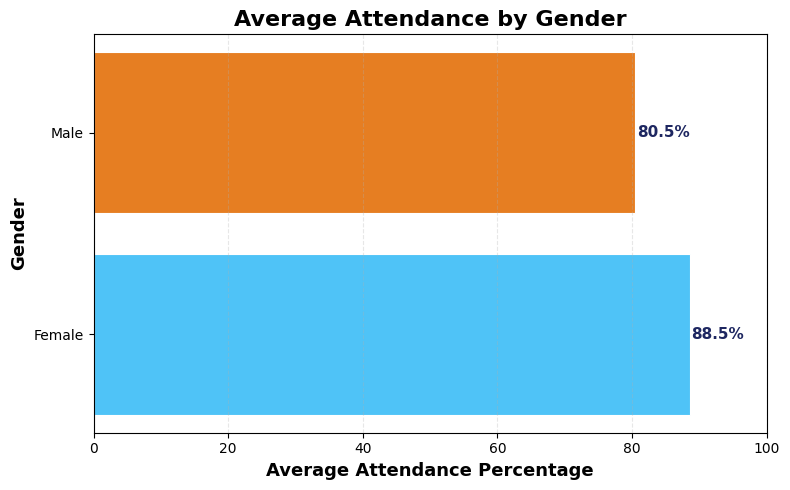

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

query_avg_attendance_gender = """
SELECT
    gender,
    ROUND(AVG(attendance_percentage), 2) AS avg_attendance
FROM students
GROUP BY gender
ORDER BY avg_attendance DESC;
"""

chart_data = pd.read_sql_query(query_avg_attendance_gender, conn)

fig, ax = plt.subplots(figsize=(8,5))

bar_colors = ["#4FC3F7", "#E67E22"]

bars = ax.barh(
    chart_data["gender"],          # Y-axis
    chart_data["avg_attendance"],  # X-axis
    color=bar_colors,
    edgecolor="white",
    linewidth=0.8
)

for bar in bars:
    width = bar.get_width()

    ax.text(
        width + 0.3,
        bar.get_y() + bar.get_height()/2,
        f'{width:.1f}%',
        va='center',
        fontsize=11,
        fontweight='bold',
        color='#1E2761'
    )

ax.set_title(
    'Average Attendance by Gender',
    fontsize=16,
    fontweight='bold'
)

ax.set_xlabel(
    'Average Attendance Percentage',
    fontsize=13,
    fontweight='bold'
)

ax.set_ylabel(
    'Gender',
    fontsize=13,
    fontweight='bold'
)

ax.set_xlim(0, 100)

ax.grid(
    axis='x',
    linestyle='--',
    alpha=0.3
)

plt.tight_layout()
plt.show()

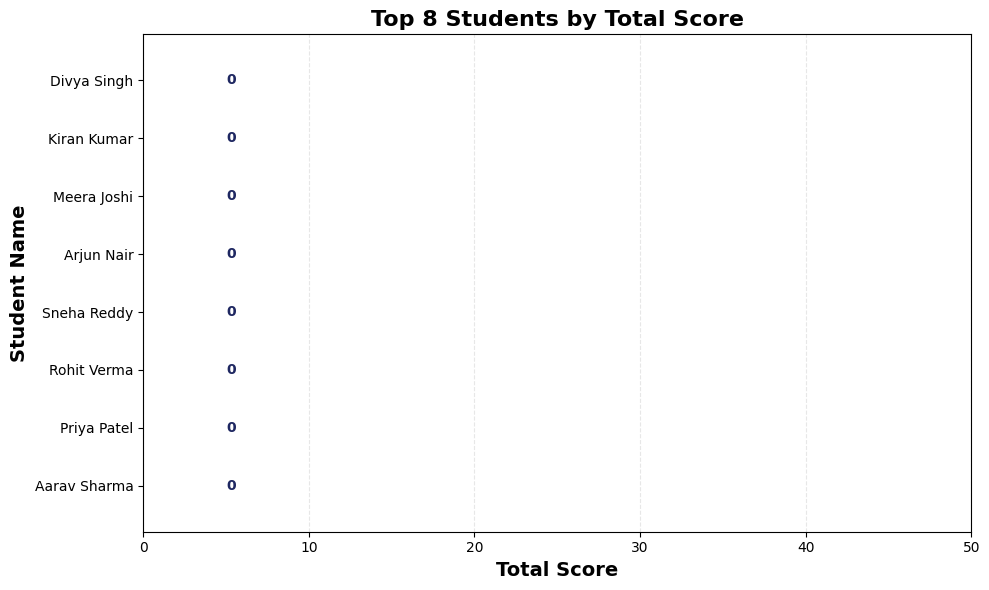

In [19]:
top_8_students_sql = """
SELECT name,
       (CAST("Math Score" AS INTEGER) + CAST("Science Score" AS INTEGER) + CAST("History Score" AS INTEGER)) AS total_score
FROM students
ORDER BY total_score DESC
LIMIT 8
"""

top_8_students_data = pd.read_sql_query(top_8_students_sql, conn)

fig, ax = plt.subplots(figsize=(10, 6))

# Define colors for the bars
bar_colors = plt.cm.viridis(top_8_students_data.index / len(top_8_students_data.index))

bars = ax.barh(
    top_8_students_data["name"], # Y-axis for names
    top_8_students_data["total_score"],
    color=bar_colors,
    edgecolor="white",
    linewidth=0.8
)

for bar in bars:
    width = bar.get_width() # Get the width of the bar for horizontal plots
    ax.text(
        width + 5, # X-position for the text
        bar.get_y() + bar.get_height() / 2, # Y-position for the text
        f'{width}',
        ha='left', # Align text to the left of the bar
        va='center',
        fontsize=10,
        fontweight='bold',
        color='#1E2761'
    )

ax.set_title(
    'Top 8 Students by Total Score',
    fontsize=16,
    fontweight='bold'
)

ax.set_xlabel(
    'Total Score', # X-axis label
    fontsize=14,
    fontweight='bold'
)

ax.set_ylabel(
    'Student Name', # Y-axis label
    fontsize=14,
    fontweight='bold'
)

ax.set_xlim(0, top_8_students_data['total_score'].max() + 50) # Adjust x-limit for better spacing
ax.tick_params(axis='y', labelsize=10) # Adjust ticks for y-axis
ax.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()